In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
features = ['Pclass', 'Sex', 'Age', 'Fare']

X = df[features]
y = df['Survived']

In [5]:
df.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

<Axes: >

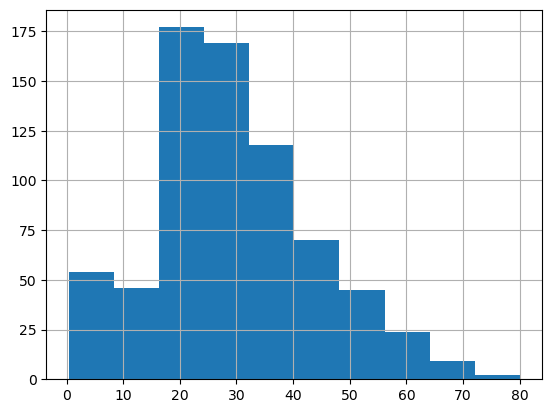

In [6]:
df['Age'].hist()

In [7]:
X['Age'] = X['Age'].fillna(X['Age'].median())

C:\Users\arnav\AppData\Local\Temp\ipykernel_31248\1341152632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = X['Age'].fillna(X['Age'].median())


In [8]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Pclass,Age,Fare,Sex_male
0,3,22.0,7.2500,True
1,1,38.0,71.2833,False
2,3,26.0,7.9250,False
3,1,35.0,53.1000,False
4,3,35.0,8.0500,True


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
from sklearn.model_selection import cross_val_score

In [12]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

[0.82503294 0.83475936 0.84137701 0.8421123  0.86105571]
Mean ROC-AUC: 0.8408674623709584


In [13]:
X['FamilySize'] = df['SibSp'] + df['Parch']
X['FarePerPerson'] = df['Fare'] / (X['FamilySize'] + 1)
X = pd.get_dummies(X, drop_first=True)
X.head()

,Pclass,Age,Fare,Sex_male,FamilySize,FarePerPerson
0,3,22.0,7.2500,True,1,3.62500
1,1,38.0,71.2833,False,1,35.64165
2,3,26.0,7.9250,False,0,7.92500
3,1,35.0,53.1000,False,1,26.55000
4,3,35.0,8.0500,True,0,8.05000


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from xgboost import XGBClassifier

In [17]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [18]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(xgb_cv_scores)
print("Mean XGB ROC-AUC:", xgb_cv_scores.mean())

[0.86350461 0.80995989 0.89438503 0.86891711 0.91470549]
Mean XGB ROC-AUC: 0.8702944269414624


In [19]:
X['IsChild'] = (df['Age'] < 12).astype(int)

In [20]:
X['IsAlone'] = (X['FamilySize'] == 0).astype(int)

In [21]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [22]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [23]:
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']

df['Title'] = df['Title'].apply(
    lambda x: x if x in common_titles else 'Rare'
)

In [24]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'FamilySize',
    'IsChild',
    'IsAlone',
    'Title'
]

In [27]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)
df['IsChild'] = (df['Age'] < 12).astype(int)

In [28]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'FamilySize',
    'IsChild',
    'IsAlone',
    'Title'
]

X = df[features]

In [29]:
X['Age'] = X['Age'].fillna(X['Age'].median())
X = pd.get_dummies(X, drop_first=True)

C:\Users\arnav\AppData\Local\Temp\ipykernel_31248\1064068427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = X['Age'].fillna(X['Age'].median())


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


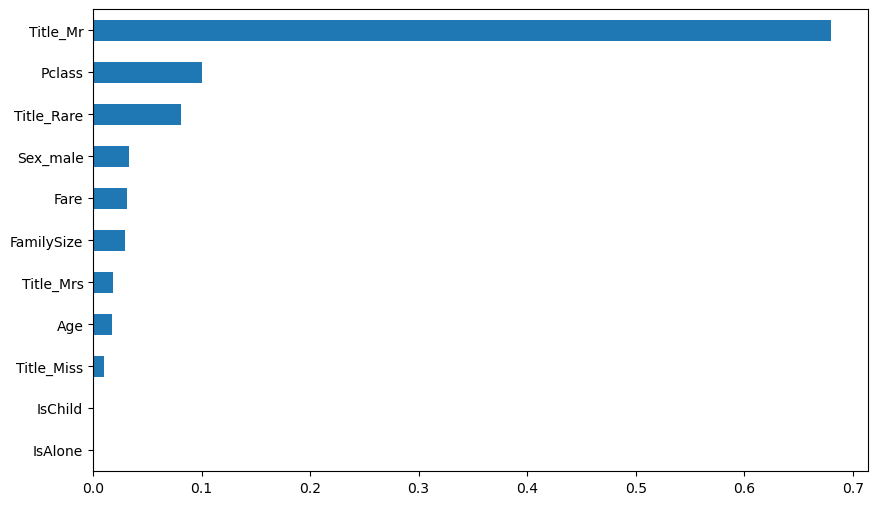

In [32]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importances.sort_values().plot(kind='barh', figsize=(10,6))

plt.show()